In [2]:
#Importing necessary libraries
import scipy.io
import numpy as np
from scipy.sparse import issparse

# Load the .mat file
mat = scipy.io.loadmat('SIS_er.mat')
# Inspect the keys
print(mat.keys())

dict_keys(['__header__', '__version__', '__globals__', 'A', 'R0', 'W0', 'beta', 'mu', 'q0', 'tRef', 'z0_full', 'zRef'])


In [3]:
# Get the 1x18 struct array
W0_structs = mat['W0'][0]  # shape (18,)
print(f"Number of orders: {len(W0_structs)}")

Number of orders: 20


In [4]:
#example for etxracting all the W0 coefficients

import scipy.io
import numpy as np
from scipy.sparse import issparse

def extract_all_orders_W0(filename, key='W0'):
    mat = scipy.io.loadmat(filename)
    W0_structs = mat[key][0]  # 1x18 struct array
    all_orders = []

    for i in range(len(W0_structs)):
        entry = W0_structs[i]
        coeffs = entry['coeffs']
        ind = entry['ind']

        # Convert from sparse if needed
        if issparse(coeffs):
            coeffs = coeffs.toarray().flatten()
        else:
            coeffs = np.array(coeffs).flatten()

        if issparse(ind):
            ind = ind.toarray().flatten().astype(int)
        else:
            ind = np.array(ind).flatten().astype(int)

        # Store in dictionary
        dictt = {'coeffs': coeffs, 'ind': ind}
        all_orders.append(dictt)

    return all_orders

In [5]:
W0_all_orders = extract_all_orders_W0('SIS_er.mat')

# Check a few
for i, order_data in enumerate(W0_all_orders):
    print(f"\nOrder {i+1}")
    print("Coefficients:", order_data['coeffs'][:5], "...")  # show first 5
    print("Indices:", order_data['ind'])


Order 1
Coefficients: [0.04892379 0.04098763 0.03887136 0.05800096 0.05009339] ...
Indices: [1]

Order 2
Coefficients: [0.00136778 0.00140532 0.00117172 0.0007285  0.00110839] ...
Indices: [2]

Order 3
Coefficients: [5.07155395e-05 5.87805230e-05 5.16812283e-05 2.91912603e-05
 3.83254769e-05] ...
Indices: [3]

Order 4
Coefficients: [2.36356554e-06 3.01493203e-06 2.87115285e-06 1.37840769e-06
 1.87256656e-06] ...
Indices: [4]

Order 5
Coefficients: [1.26826281e-07 1.77062866e-07 1.80650555e-07 7.48019838e-08
 1.08210846e-07] ...
Indices: [5]

Order 6
Coefficients: [7.47765750e-09 1.13739008e-08 1.23081950e-08 4.47889176e-09
 6.89010480e-09] ...
Indices: [6]

Order 7
Coefficients: [4.72178803e-10 7.79130377e-10 8.87463084e-10 2.87050104e-10
 4.69098195e-10] ...
Indices: [7]

Order 8
Coefficients: [3.13946972e-11 5.60132450e-11 6.67567006e-11 1.93186889e-11
 3.35364441e-11] ...
Indices: [8]

Order 9
Coefficients: [2.17192688e-12 4.18065001e-12 5.18906571e-12 1.34799142e-12
 2.48816058e-1

In [6]:
#extracting all the R0 coeffciecnts
import scipy.io
import numpy as np
from scipy.sparse import issparse

def extract_R0_sparse(matfile, key='R0'):
    mat = scipy.io.loadmat(matfile)
    R0_structs = mat[key][0]  # 1x18 struct array

    r0_list = []

    for i, entry in enumerate(R0_structs):
        coeffs = entry['coeffs']
        ind = entry['ind']

        # Convert from sparse if needed
        if issparse(coeffs):
            coeffs = coeffs.toarray().flatten()[0]
        else:
            coeffs = np.array(coeffs).flatten()[0]

        if issparse(ind):
            ind = ind.toarray().flatten()[0]
        else:
            ind = np.array(ind).flatten()[0]

        r0_list.append({'coeff': coeffs, 'ind': int(ind)})

    return r0_list

In [7]:
r0_terms = extract_R0_sparse('SIS_er.mat', key='R0')
print(r0_terms)
# Print all 18 terms
for i, term in enumerate(r0_terms):
    print(f"Order {i+1}: coeff = {term['coeff']}, ind = {term['ind']}")

[{'coeff': 3.4313808825359047, 'ind': 1}, {'coeff': -0.3797124653877784, 'ind': 2}, {'coeff': 0.0023981631196799765, 'ind': 3}, {'coeff': 2.3734982732355264e-05, 'ind': 4}, {'coeff': 2.0516182539452286e-06, 'ind': 5}, {'coeff': 1.2054862446575244e-07, 'ind': 6}, {'coeff': 7.616477253563447e-09, 'ind': 7}, {'coeff': 5.25827227162538e-10, 'ind': 8}, {'coeff': 3.838668070996923e-11, 'ind': 9}, {'coeff': 2.9182165098372318e-12, 'ind': 10}, {'coeff': 2.2898532119433157e-13, 'ind': 11}, {'coeff': 1.842931344523009e-14, 'ind': 12}, {'coeff': 1.5143198641462456e-15, 'ind': 13}, {'coeff': 1.2660009481992964e-16, 'ind': 14}, {'coeff': 1.0740076468404978e-17, 'ind': 15}, {'coeff': 9.226436316614308e-19, 'ind': 16}, {'coeff': 8.012926013531183e-20, 'ind': 17}, {'coeff': 7.025730430914884e-21, 'ind': 18}, {'coeff': 6.212281460368288e-22, 'ind': 19}, {'coeff': 5.534348543518515e-23, 'ind': 20}]
Order 1: coeff = 3.4313808825359047, ind = 1
Order 2: coeff = -0.3797124653877784, ind = 2
Order 3: coeff 

### 🔹 Cell 7: Constructing R0 from taylor sereis coeffients R0




In [8]:
#reconstructing taylor series using R0

import sympy as sy

# Define the reduced coordinate symbol
eta = sy.symbols('eta')  # this is your reduced coordinate

# Initialize symbolic reduced dynamics
reduced_dyn = 0

# Loop through all R₀ terms
for term in r0_terms:  # assuming r0_terms is the list extracted using extract_R0_sparse()
    coeff = term['coeff']
    ind = term['ind']
    reduced_dyn += coeff * eta**ind

# Display the symbolic reduced dynamics
print("Symbolic Reduced Dynamics:")
sy.pprint(reduced_dyn)

import sympy as sy

# Define symbolic variable
eta = sy.symbols('eta')

# Build the symbolic expression from R0 terms
reduced_dyn = 0
for term in r0_terms:  # assuming r0_terms is a list of {'coeff': ..., 'ind': ...}
    reduced_dyn += term['coeff'] * eta**term['ind']

# Convert symbolic expression to numerical function
reduced_dyn_func = sy.lambdify(eta, reduced_dyn, modules='numpy')

Symbolic Reduced Dynamics:
                      20                         19                         18
5.53434854351852e-23⋅η   + 6.21228146036829e-22⋅η   + 7.02573043091488e-21⋅η  

                         17                         16                        
 + 8.01292601353118e-20⋅η   + 9.22643631661431e-19⋅η   + 1.0740076468405e-17⋅η

15                        14                         13                       
   + 1.2660009481993e-16⋅η   + 1.51431986414625e-15⋅η   + 1.84293134452301e-14

  12                         11                         10                    
⋅η   + 2.28985321194332e-13⋅η   + 2.91821650983723e-12⋅η   + 3.83866807099692e

     9                         8                        7                     
-11⋅η  + 5.25827227162538e-10⋅η  + 7.61647725356345e-9⋅η  + 1.20548624465752e-

   6                        5                        4                        
7⋅η  + 2.05161825394523e-6⋅η  + 2.37349827323553e-5⋅η  + 0.00239816311967998⋅η

3                  

### 🔹 Cell 6: Padé Approximation Function Import

Imports the `taylor_to_pade` function from a utility script. This will be used to convert the Taylor series into a Padé approximant.


In [9]:
import numpy as np

# Assume: 
# - eta_vals is the time series η(t) from the integrator
# - W0_all_orders is the list extracted using `extract_all_orders_W0`

def reconstruct_full_state(eta_vals, W0_all_orders):
    n_nodes = len(W0_all_orders[0]['coeffs'])  # number of state variables (e.g., 200)
    n_times = len(eta_vals)
    
    x_full = np.zeros((n_nodes, n_times), dtype=np.float64)
    
    for k, wk in enumerate(W0_all_orders):
        coeffs = wk['coeffs'].flatten()  # shape: (n_nodes,)
        ind = wk['ind'].flatten()[0]     # scalar: monomial order
        if len(coeffs) == 0:
            continue  # skip if empty
        x_full += np.outer(coeffs, eta_vals**ind)
    
    return x_full

In [10]:
W0_all_orders = extract_all_orders_W0('SIS_er.mat')

# Check a few
for i, order_data in enumerate(W0_all_orders):
    print(f"\nOrder {i+1}")
    print("Coefficients:", order_data['coeffs'][:5], "...")  # show first 5
    print("Indices:", order_data['ind'])


Order 1
Coefficients: [0.04892379 0.04098763 0.03887136 0.05800096 0.05009339] ...
Indices: [1]

Order 2
Coefficients: [0.00136778 0.00140532 0.00117172 0.0007285  0.00110839] ...
Indices: [2]

Order 3
Coefficients: [5.07155395e-05 5.87805230e-05 5.16812283e-05 2.91912603e-05
 3.83254769e-05] ...
Indices: [3]

Order 4
Coefficients: [2.36356554e-06 3.01493203e-06 2.87115285e-06 1.37840769e-06
 1.87256656e-06] ...
Indices: [4]

Order 5
Coefficients: [1.26826281e-07 1.77062866e-07 1.80650555e-07 7.48019838e-08
 1.08210846e-07] ...
Indices: [5]

Order 6
Coefficients: [7.47765750e-09 1.13739008e-08 1.23081950e-08 4.47889176e-09
 6.89010480e-09] ...
Indices: [6]

Order 7
Coefficients: [4.72178803e-10 7.79130377e-10 8.87463084e-10 2.87050104e-10
 4.69098195e-10] ...
Indices: [7]

Order 8
Coefficients: [3.13946972e-11 5.60132450e-11 6.67567006e-11 1.93186889e-11
 3.35364441e-11] ...
Indices: [8]

Order 9
Coefficients: [2.17192688e-12 4.18065001e-12 5.18906571e-12 1.34799142e-12
 2.48816058e-1

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.interpolate import pade
import sympy as sy

# === Build Taylor-based reduced dynamics ===
eta = sy.symbols('eta')
reduced_dyn_taylor = 0
max_order = 0
for term in r0_terms:
    reduced_dyn_taylor += term['coeff'] * eta**term['ind']
    max_order = max(max_order, term['ind'])

reduced_dyn_func = sy.lambdify(eta, reduced_dyn_taylor, modules='numpy')

# === Extract coefficients for Padé approximation ===
taylor_coeffs = np.zeros(max_order + 1)
for term in r0_terms:
    taylor_coeffs[term['ind']] = term['coeff']

m, n = 2, 2  # Padé [m/n] order (adjustable)
p_poly, q_poly = pade(taylor_coeffs, m)


def reduced_dyn_pade(eta):
    return p_poly(eta) / q_poly(eta)

# === Define RHS for integration ===
def rhs_taylor(t, eta): return reduced_dyn_func(eta)
def rhs_pade(t, eta): return reduced_dyn_pade(eta)

# === Integration settings ===
t_span = (0, 50)
t_eval = np.linspace(*t_span, 500)
eta0 = [0.01]

# === Integrate both systems ===
sol_taylor = solve_ivp(rhs_taylor, t_span, eta0,t_eval=t_eval, rtol=1e-9, atol=1e-12)
sol_pade = solve_ivp(rhs_pade, t_span, eta0, t_eval=t_eval, method='DOP853',rtol=1e-9, atol=1e-12)

# === Reconstruct full state ===
eta_taylor = sol_taylor.y[0]
eta_pade = sol_pade.y[0]

x_taylor = reconstruct_full_state(eta_taylor, W0_all_orders)
x_pade = reconstruct_full_state(eta_pade, W0_all_orders)

# === Compute average activity over nodes ===
x_avg_taylor = np.mean(x_taylor, axis=0)
x_avg_pade = np.mean(x_pade, axis=0)

# === Compute difference ===
diff = np.linalg.norm(x_avg_pade - x_avg_taylor) / np.linalg.norm(x_avg_taylor)
print(f"Relative difference between Taylor and Padé reconstructions: {diff:.2e}")



Relative difference between Taylor and Padé reconstructions: 1.87e-03


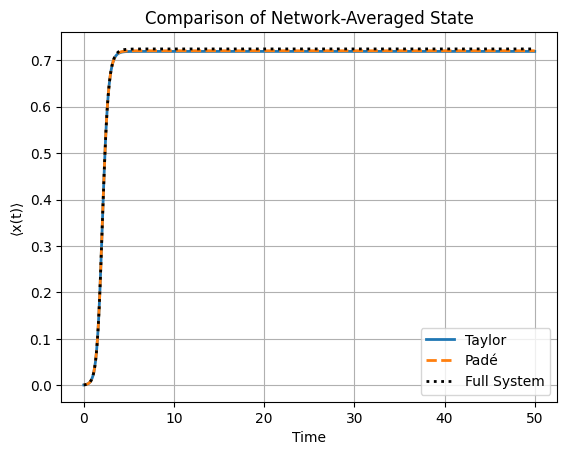

In [15]:
import scipy.io
import numpy as np
import matplotlib.pyplot as plt

# === Load full system data ===
mat = scipy.io.loadmat('SIS_er.mat')
zRef = mat['zRef']        # shape: (n_time, n_nodes)
tRef = mat['tRef'].squeeze()

# === Compute mean across nodes
x_avg_full = np.mean(zRef, axis=1)  # shape: (n_time,)

#plt.ylim(0.7, 0.8)  # optional: tighten for visual clarity

# === Plot again without ylim
plt.plot(sol_taylor.t, x_avg_taylor, label="Taylor", linewidth=2)
plt.plot(sol_pade.t, x_avg_pade, '--', label="Padé", linewidth=2)
plt.plot(tRef, x_avg_full, ':k', label="Full System", linewidth=2)
plt.xlabel("Time")
plt.ylabel("⟨x(t)⟩")
plt.title("Comparison of Network-Averaged State")
plt.legend()
plt.grid(True)
plt.show()